In [8]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
interventions = pd.read_csv('intervention_summary.csv')
interventions.head()

,repeat,fold,time_step,baseline_accuracy,baseline_f1,intervention_accuracy,intervention_f1,fn_to_tp,fp_to_tn,tp_to_fn,tn_to_fp,net_improvement,experiment_dir
0,0,0,0,0.606061,0.66087,0.606061,0.660870,0,0,0,0,0,0_0
1,0,0,1,0.606061,0.66087,0.595960,0.649123,0,0,2,0,-2,0_0
2,0,0,2,0.606061,0.66087,0.616162,0.669565,3,2,2,1,2,0_0
3,0,0,3,0.606061,0.66087,0.631313,0.678414,5,5,4,1,5,0_0
4,0,0,4,0.606061,0.66087,0.636364,0.678571,4,7,4,1,6,0_0


In [10]:
avg_by_fold = (
    interventions.groupby(["fold", "time_step"])["intervention_f1"] 
      .mean()
      .reset_index(name="f1_mean")
      .sort_values(by="fold")
)
step4_v_base = avg_by_fold[avg_by_fold['time_step'].isin([0,4])]

In [17]:
avg_by_fold

,fold,time_step,f1_mean
0,0,0,0.719155
1,0,1,0.717486
2,0,2,0.724836
3,0,3,0.728729
4,0,4,0.732674
9,1,4,0.740948
7,1,2,0.735908
8,1,3,0.746126
5,1,0,0.743743
6,1,1,0.742782


In [40]:
avg_by_fold[avg_by_fold['time_step']==4]['f1_mean'].median()

np.float64(0.7344867301552446)

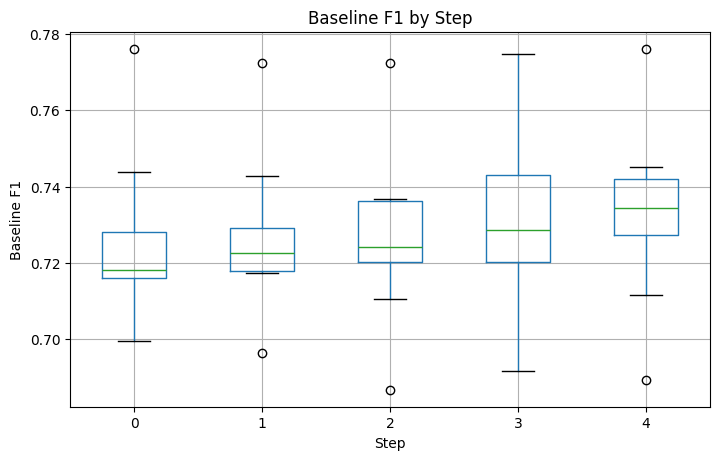

In [11]:

avg_by_fold.boxplot(column="f1_mean", by="time_step", figsize=(8, 5))

plt.title("Baseline F1 by Step")
plt.suptitle("")   # removes the automatic 'baseline_f1 by step' subtitle
plt.xlabel("Step")
plt.ylabel("Baseline F1")
plt.show()

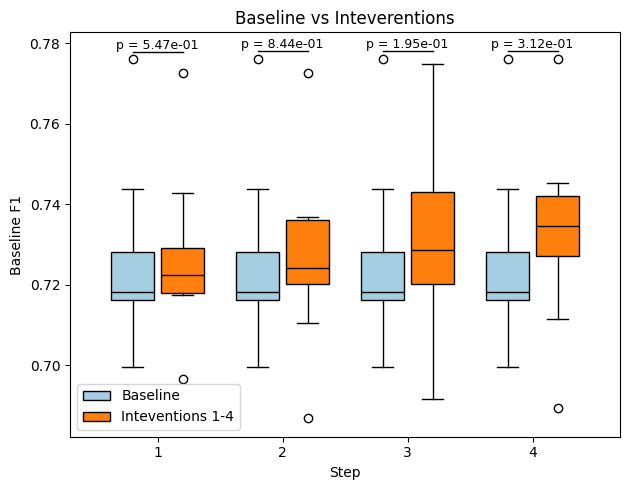

In [23]:
df = avg_by_fold
df["time_step"] = pd.to_numeric(df["time_step"], errors="coerce")

baseline = df.loc[df["time_step"] == 0, "f1_mean"]

steps = sorted(df["time_step"].dropna().unique())
steps = [s for s in steps if s != 0]

fig, ax = plt.subplots(figsize=(1.6*len(steps), 5))

baseline_color = "#a6cee3"   # light pastel blue
other_color = "#ff7f0e"      # light pastel red/orange

data_ymax = []
for i, s in enumerate(steps, start=1):
    current = df.loc[df["time_step"] == s, "f1_mean"]
    
    bp1 = ax.boxplot([baseline], positions=[i - 0.2], widths=0.35, patch_artist=True)
    for patch in bp1['boxes']:
        patch.set_facecolor(baseline_color)
    for median in bp1['medians']:
        median.set_color("black")
    
    bp2 = ax.boxplot([current], positions=[i + 0.2], widths=0.35, patch_artist=True)
    for patch in bp2['boxes']:
        patch.set_facecolor(other_color)
    for median in bp2['medians']:
        median.set_color("black")
        
    data_ymax.append(np.nanmax([baseline.max(), current.max()]))

    # look up precomputed p-value
    p = pvals_df.loc[pvals_df["time_step"] == s, "p_value"].squeeze() if 'pvals_df' in globals() else np.nan
    txt = f"p = {p:.2e}" if pd.notna(p) else "p = n/a"

    # annotate
    y = data_ymax[-1] + 0.02*(ax.get_ylim()[1] - ax.get_ylim()[0])
    ax.plot([i - 0.2, i + 0.2], [y, y], color="black", linewidth=1.0)
    ax.text(i, y, txt, ha="center", va="bottom", fontsize=9)


ax.set_xticks(range(1, len(steps)+1))
ax.set_xticklabels(steps)

ax.set_xlabel("Step")
ax.set_ylabel("Baseline F1")
ax.set_title("Baseline vs Inteverentions")

# legend
legend_patches = [
    plt.Rectangle((0,0),1,1,facecolor=baseline_color, edgecolor="black"),
    plt.Rectangle((0,0),1,1,facecolor=other_color, edgecolor="black")
]
ax.legend(legend_patches, ["Baseline", "Inteventions 1-4"], loc="best")

plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import wilcoxon

# Load
df = avg_by_fold
df["step"] = pd.to_numeric(df["time_step"], errors="coerce")
ycol = "f1_mean"

# Pairing keys (adjust if your pairing unit differs)
pair_keys = ["fold"] + (["repeat"] if "repeat" in df.columns else [])

# Baseline rows
b = df[df["time_step"] == 0][pair_keys + [ycol]].rename(columns={ycol: "y0"})

pvals = []
for s in sorted(df["time_step"].dropna().unique()):
    if s == 0: 
        continue
    c = df[df["time_step"] == s][pair_keys + [ycol]].rename(columns={ycol: "y1"})
    m = pd.merge(b, c, on=pair_keys, how="inner").dropna(subset=["y0","y1"])
    n_pairs = len(m)

    if n_pairs == 0:
        stat, p = np.nan, np.nan
    else:
        # Handle the “all differences are zero” case gracefully
        try:
            stat, p = wilcoxon(m["y0"], m["y1"], alternative="two-sided")
        except ValueError:
            stat, p = 0.0, 1.0

    pvals.append({"time_step": s, "n_pairs": n_pairs, "stat": stat, "p_value": f"{p:.3f}"})

pvals_df = pd.DataFrame(pvals).sort_values("time_step").reset_index(drop=True)
print(pvals_df)

   time_step  n_pairs  stat p_value
0          1        8  13.0   0.547
1          2        8  16.0   0.844
2          3        8   8.0   0.195
3          4        8  10.0   0.312


In [28]:
import statsmodels.formula.api as smf
import statsmodels.api as sm


avg_by_fold["step_num"] = pd.to_numeric(avg_by_fold["time_step"], errors="coerce")

# Define variables
X = sm.add_constant(avg_by_fold[["step_num"]])
y = avg_by_fold["f1_mean"]

# Fit regression
model = sm.OLS(y, X).fit()

#print(m.summary())
#print("\nSlope for step:", m.params["step_num"])

/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_72768/843060408.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


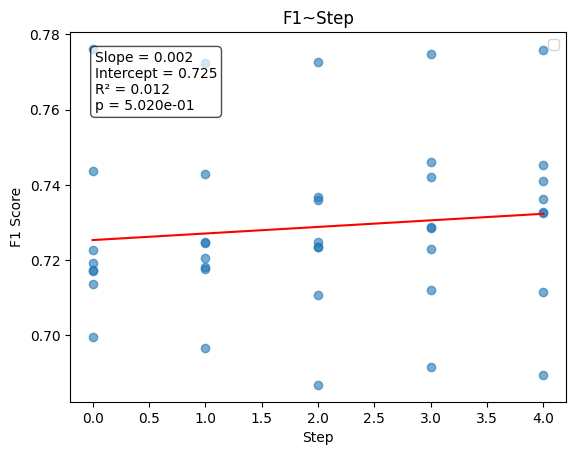

In [29]:
slope = model.params["step_num"]
intercept = model.params["const"]
r2 = model.rsquared
pval = model.pvalues["step_num"]

# Scatter plot
plt.scatter(avg_by_fold["step_num"], y, alpha=0.6)

# Regression line
x_vals = pd.Series(sorted(avg_by_fold["step_num"].unique()))
y_pred = intercept + slope * x_vals
plt.plot(x_vals, y_pred, color="red")

# Labels
plt.xlabel("Step")
plt.ylabel("F1 Score")
plt.title("F1~Step")

# Annotation text
textstr = f"Slope = {slope:.3f}\nIntercept = {intercept:.3f}\nR² = {r2:.3f}\np = {pval:.3e}"
plt.gca().text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.7)
)

plt.legend()
plt.show()

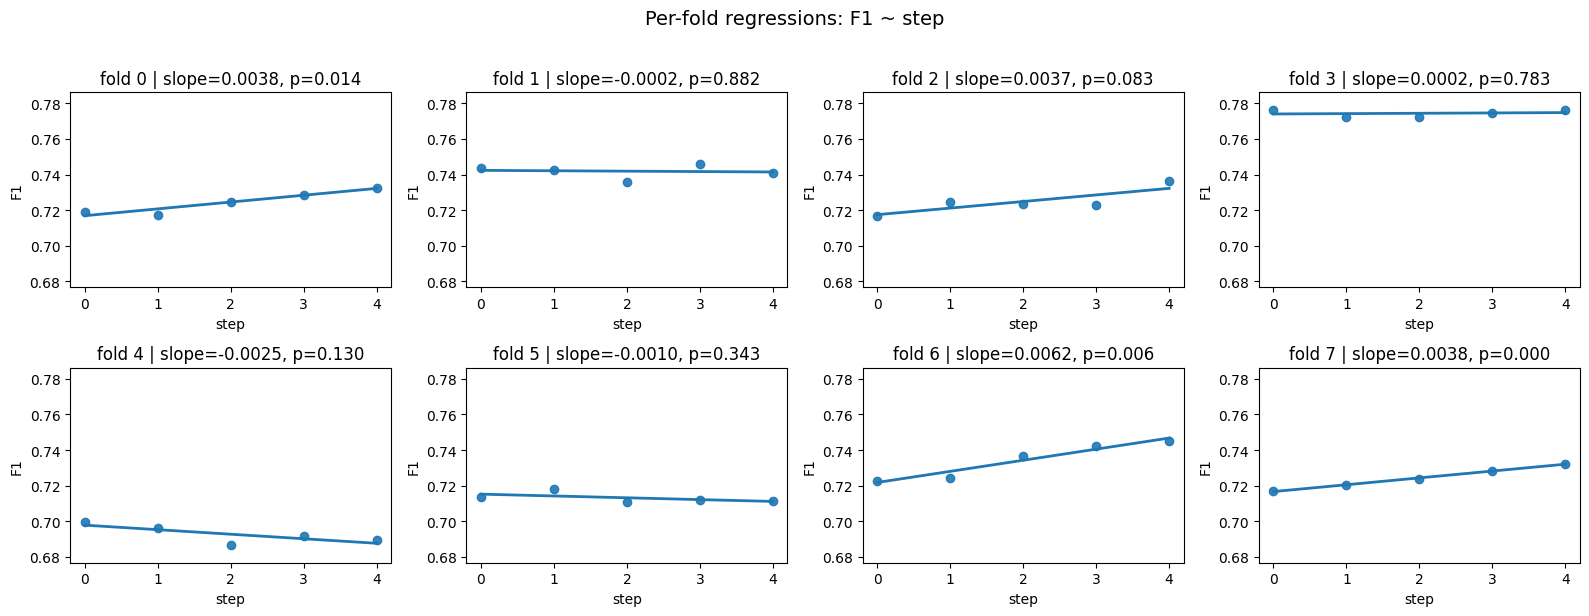

In [30]:
df=avg_by_fold
xcol = 'step' if 'step' in df.columns else 'time_step'
ycol = 'f1_mean'

folds = sorted(df['fold'].unique(), key=lambda v: int(v) if str(v).isdigit() else str(v))
n = len(folds)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), squeeze=False)

for i, f in enumerate(folds):
    ax = axes[i//cols, i%cols]
    sub = df[df['fold'] == f].sort_values(xcol)

    # scatter
    ax.scatter(sub[xcol], sub[ycol], alpha=0.9)

    X = sm.add_constant(sub[[xcol]], has_constant='add')  # DataFrame in, DataFrame out
    y = sub[ycol]
    model = sm.OLS(y, X).fit()

    # fitted line
    xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
    ys = model.params['const'] + model.params[xcol] * xs
    ax.plot(xs, ys, linewidth=2)

    # title with slope & p-value
    ax.set_title(f"fold {f} | slope={model.params[xcol]:.4f}, p={model.pvalues[xcol]:.3f}")
    ax.set_xlabel("step")
    ax.set_ylabel("F1")
    ax.set_xticks(sorted(sub[xcol].unique()))
    ax.set_ylim(max(0.0, df[ycol].min()-0.01), min(1.0, df[ycol].max()+0.01))

# hide any empty panels
for j in range(i+1, rows*cols):
    axes[j//cols, j%cols].axis('off')

fig.suptitle("Per-fold regressions: F1 ~ step", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


slope_step = 0.0017 (p=0.500), slope_fold = -0.0019 (p=0.249), R^2 = 0.047


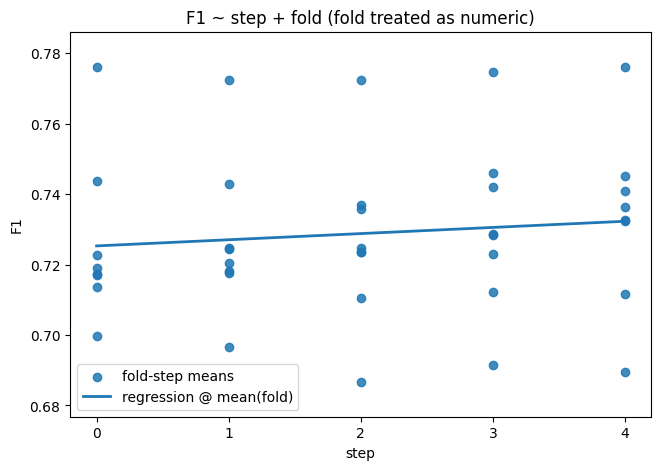

In [31]:
df = avg_by_fold

# df must have: 'fold', 'f1_mean', and either 'step' or 'time_step'
xcol = 'step' if 'step' in df.columns else 'time_step'

# Fit the mis-specified pooled model: fold treated as numeric
m = smf.ols(f"f1_mean ~ {xcol} + fold", data=df).fit()

# Scatter of all points
plt.figure(figsize=(7.5,5))
plt.scatter(df[xcol], df['f1_mean'], alpha=0.85, label='fold-step means')

# Fitted line at the average fold value (for visualization)
xs = np.linspace(df[xcol].min(), df[xcol].max(), 200)
fold_avg = df['fold'].mean()
ys = (m.params['Intercept']
      + m.params[xcol] * xs
      + m.params['fold'] * fold_avg)
plt.plot(xs, ys, linewidth=2, label='regression @ mean(fold)')

# Cosmetics
plt.xlabel('step')
plt.ylabel('F1')
plt.title('F1 ~ step + fold (fold treated as numeric)')
plt.xticks(sorted(df[xcol].unique()))
plt.ylim(max(0.0, df['f1_mean'].min()-0.01), min(1.0, df['f1_mean'].max()+0.01))
plt.legend()

# (Optional) print a tiny summary line
print(f"slope_step = {m.params[xcol]:.4f} (p={m.pvalues[xcol]:.3f}), "
      f"slope_fold = {m.params['fold']:.4f} (p={m.pvalues['fold']:.3f}), "
      f"R^2 = {m.rsquared:.3f}")

plt.show()


In [32]:
import statsmodels.formula.api as smf

xcol = 'step' if 'step' in df.columns else 'time_step'
m = smf.ols(f"f1_mean ~ {xcol} + fold", data=df).fit()

# Full regression output
print(m.summary())

# Or a compact printout
print("\n== Compact results ==")
print(f"Intercept: {m.params['Intercept']:.6f}")
print(f"{xcol} coef: {m.params[xcol]:.6f}  (SE {m.bse[xcol]:.6f}, p {m.pvalues[xcol]:.4f})")
print(f"fold coef: {m.params['fold']:.6f}  (SE {m.bse['fold']:.6f}, p {m.pvalues['fold']:.4f})")
print(f"R^2 = {m.rsquared:.4f},  Adj R^2 = {m.rsquared_adj:.4f},  n = {int(m.nobs)}")
import statsmodels.formula.api as smf

                            OLS Regression Results                            
Dep. Variable:                f1_mean   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.9183
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.408
Time:                        20:25:45   Log-Likelihood:                 95.738
No. Observations:                  40   AIC:                            -185.5
Df Residuals:                      37   BIC:                            -180.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7318      0.008     87.235      0.0

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

df = avg_by_fold
#df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Fixed effects via LSDV (fold intercepts)
res_lsdv = smf.ols("f1_mean ~ time_step + C(fold)", data=df).fit(cov_type="HC1")
lsdv_tab = res_lsdv.summary2().tables[1].reset_index().rename(columns={"index":"term"})
lsdv_tab.to_csv("fixed_effects_LSDV_coefficients.csv", index=False)

# Within (demeaned by fold): removes fold-specific intercepts
df_w = df.copy()
df_w["f1_w"] = df_w["f1_mean"] - df_w.groupby("fold")["f1_mean"].transform("mean")
df_w["time_step_w"] = df_w["time_step"] - df_w.groupby("fold")["time_step"].transform("mean")
res_within = sm.OLS(df_w["f1_w"], df_w[["time_step_w"]]).fit(cov_type="HC1")
within_tab = res_within.summary2().tables[1].reset_index().rename(columns={"index":"term"})

# >>> native summary for the within model
print("\n=== OLS summary (Within FE on demeaned data) ===")
print(res_within.summary())
with open("ols_summary_within.txt", "w") as f:
    f.write(res_within.summary().as_text())

# Quick console snippets
print("Rows after averaging:", len(df))
print("\nLSDV (time_step):\n", lsdv_tab[lsdv_tab["term"] == "time_step"])
print("\nWithin (time_step_w):\n", within_tab[within_tab["term"] == "time_step_w"])


=== OLS summary (Within FE on demeaned data) ===
                                 OLS Regression Results                                
Dep. Variable:                   f1_w   R-squared (uncentered):                   0.215
Model:                            OLS   Adj. R-squared (uncentered):              0.195
Method:                 Least Squares   F-statistic:                              7.915
Date:                Sun, 21 Sep 2025   Prob (F-statistic):                     0.00764
Time:                        23:24:06   Log-Likelihood:                          157.42
No. Observations:                  40   AIC:                                     -312.8
Df Residuals:                      39   BIC:                                     -311.2
Df Model:                           1                                                  
Covariance Type:                  HC1                                                  
                  coef    std err          z      P>|z|      [0.025   

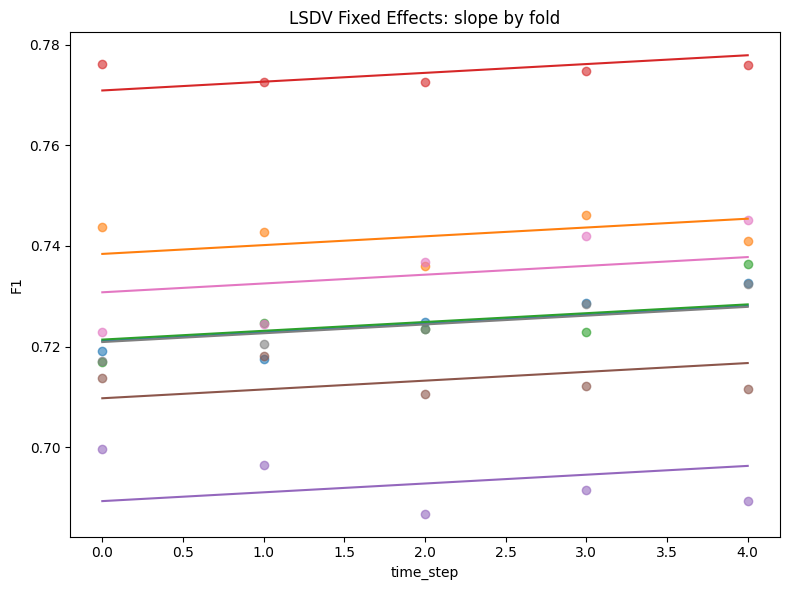

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Fit LSDV model
res_lsdv = smf.ols("f1_mean ~ time_step + C(fold)", data=avg_by_fold).fit(cov_type="HC1")

# Extract slope (same for all folds)
beta = res_lsdv.params["time_step"]

# Build predictions for each fold
plt.figure(figsize=(8,6))
for fold in avg_by_fold["fold"].unique():
    # intercept for this fold = overall intercept + fold dummy (if present)
    intercept = res_lsdv.params["Intercept"]
    if f"C(fold)[T.{fold}]" in res_lsdv.params:
        intercept += res_lsdv.params[f"C(fold)[T.{fold}]"]

    # range of time steps for this fold
    x_vals = np.linspace(avg_by_fold["time_step"].min(), avg_by_fold["time_step"].max(), 100)
    y_vals = intercept + beta * x_vals

    # plot data points and fitted line
    df_fold = avg_by_fold[avg_by_fold["fold"] == fold]
    plt.scatter(df_fold["time_step"], df_fold["f1_mean"], alpha=0.6, label=f"fold {fold} data")
    plt.plot(x_vals, y_vals, label=f"fold {fold} fit")

plt.xlabel("time_step")
plt.ylabel("F1")
plt.title("LSDV Fixed Effects: slope by fold")
plt.tight_layout()
plt.savefig("lsdv_fixed_effects_lines.png", dpi=150)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Load


df = avg_by_fold

# Treat step as categorical with a sensible order
# (If step is numeric-like strings, this will sort them numerically)
try:
    step_order = sorted(df["time_step"].unique(), key=lambda x: float(x))
except Exception:
    step_order = sorted(df["time_step"].unique(), key=lambda x: str(x))

df["time_step"] = pd.Categorical(df["time_step"], categories=step_order, ordered=True)

# Fit categorical model for overall R² and ANOVA p-value
m_cat = smf.ols("f1_mean ~ C(time_step)", data=df).fit()
r2 = m_cat.rsquared
anova_tbl = sm.stats.anova_lm(m_cat, typ=2)
overall_p = anova_tbl.loc["C(time_step)", "PR(>F)"]

# Jittered scatter
x_lookup = {cat: i for i, cat in enumerate(step_order)}
x = df["time_step"].map(x_lookup).astype(float).values
jitter = (np.random.rand(len(x)) - 0.5) * 0.2  # narrow jitter
plt.scatter(x + jitter, df["f1_mean"], alpha=0.6, label="Points")

# Mean ± SE per step
g = df.groupby("time_step")["f1_mean"]
means = g.mean()
ses = g.std(ddof=1) / np.sqrt(g.size())
xs = np.arange(len(step_order))
plt.errorbar(xs, means.values, yerr=ses.values, fmt="o", capsize=3, label="Mean ± SE")

# Axes & labels
plt.xticks(xs, step_order)
plt.xlabel("Step (categorical)")
plt.ylabel("F1 score")
plt.title("F1 by Step (categorical)")

# Annotate overall fit stats
textstr = f"R² = {r2:.3f}\nANOVA p = {overall_p:.3e}"
plt.gca().text(
    0.02, 0.98, textstr, transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

m_cat = smf.ols("f1_mean ~ C(time_step)", data=avg_by_fold).fit()
print(m_cat.summary())

# Optional: ANOVA table
print("\nANOVA (Type II):")
print(sm.stats.anova_lm(m_cat, typ=2))

/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_72134/3987227954.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=means.index, y=means.values*100, color="skyblue", ci=None)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/delta_f1_barchart.png'

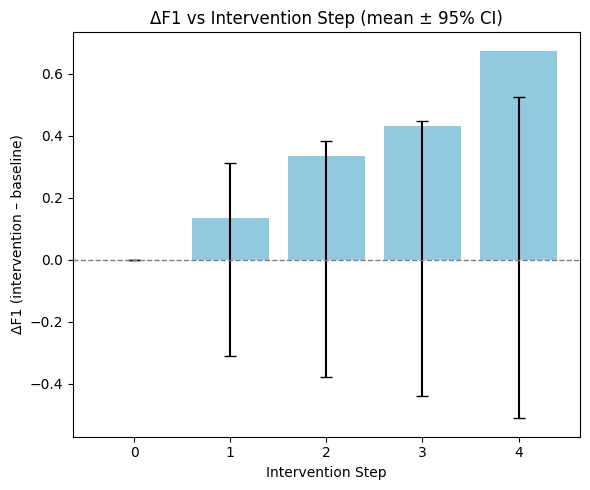

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv("../intervention_summary_1.csv")

# Compute delta F1
df["delta_f1"] = df["intervention_f1"] - df["baseline_f1"]

# Average across repeats within (fold, step)
avg = df.groupby(["fold", "time_step"])["delta_f1"].mean().reset_index()

# Mean and 95% CI across folds
means = avg.groupby("time_step")["delta_f1"].mean()
cis = avg.groupby("time_step")["delta_f1"].apply(
    lambda x: 100*(1.96 * x.std() / np.sqrt(len(x)))
)

# Plot as bar chart
plt.figure(figsize=(6,5))
sns.barplot(x=means.index, y=means.values*100, color="skyblue", ci=None)
plt.errorbar(means.index, means.values, yerr=cis.values, fmt='none', c='black', capsize=4)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("ΔF1 vs Intervention Step (mean ± 95% CI)")
plt.ylabel("ΔF1 (intervention – baseline)")
plt.xlabel("Intervention Step")
plt.tight_layout()
plt.savefig("/mnt/data/delta_f1_barchart.png", dpi=200)
plt.close()


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_72134/2059778593.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=means_pct.index, y=means_pct.values, color="skyblue", ci=None)


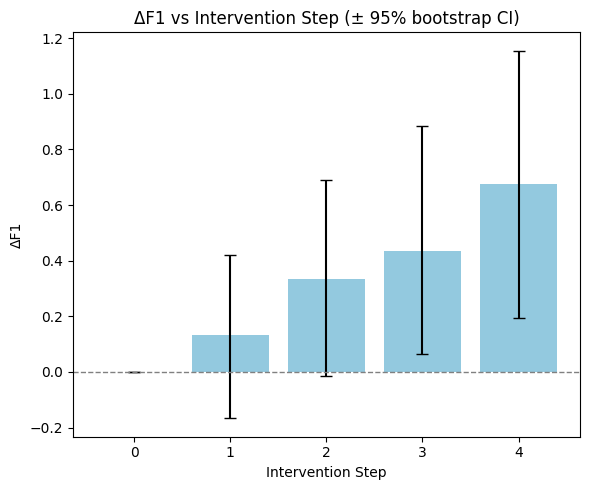

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load your data ---
df = pd.read_csv("../intervention_summary_1.csv")

# Compute ΔF1 (intervention – baseline)
df["delta_f1"] = df["intervention_f1"] - df["baseline_f1"]

# Average across repeats within (fold, step)
avg = df.groupby(["fold", "time_step"])["delta_f1"].mean().reset_index()

# --- Bootstrap CI function ---
def bootstrap_ci(data, n_boot=10000, ci=95):
    boot_means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(sample.mean())
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100 - (100-ci)/2)
    return lower, upper

# Compute mean and bootstrap CIs
means = avg.groupby("time_step")["delta_f1"].mean()
cis = avg.groupby("time_step")["delta_f1"].apply(lambda x: bootstrap_ci(x.values))
ci_lower = [ci[0] for ci in cis]
ci_upper = [ci[1] for ci in cis]

# Convert to percentage points
means_pct = means * 100
ci_lower_pct = np.array(ci_lower) * 100
ci_upper_pct = np.array(ci_upper) * 100

# --- Plot ---
plt.figure(figsize=(6,5))
sns.barplot(x=means_pct.index, y=means_pct.values, color="skyblue", ci=None)
plt.errorbar(means_pct.index, means_pct.values, 
             yerr=[means_pct.values-ci_lower_pct, ci_upper_pct-means_pct.values], 
             fmt='none', c='black', capsize=4)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("ΔF1 vs Intervention Step (± 95% bootstrap CI)")
plt.ylabel("ΔF1")
plt.xlabel("Intervention Step")
plt.tight_layout()
plt.savefig('intervention_f1.png')
plt.show()
